# **Deep Learning & Generative AI — Lab 3 Fashion-MNIST**

The goal of this session is to build a neural network that classifies **clothing items** into 10 categories (**multi-class classification**). However, note that this notebook **does not work as is**. Your task is to iterate on the code until it meets the requirements.

Fashion-MNIST has exactly the same format as MNIST (28×28 grayscale, 10 classes, 60k training / 10k test samples) but is **considerably more difficult**: T-shirts, sweaters, and coats look very similar at 28×28 pixels. A linear model tops out at ~84%, and a **Dense network hits a ceiling around 90%**.
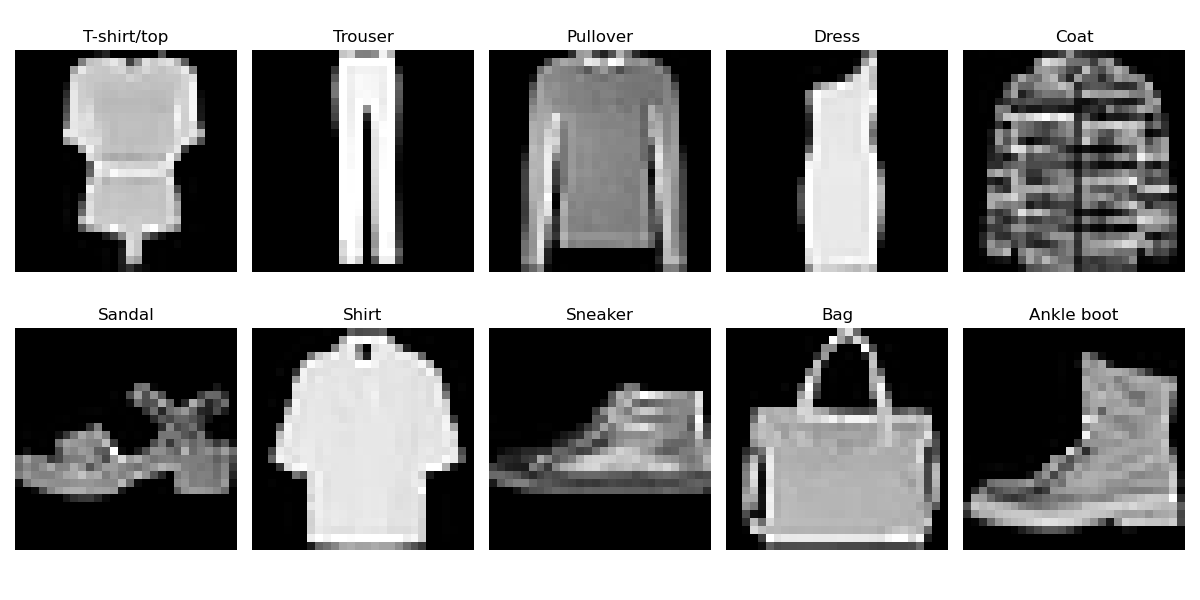

## 0. Import the required Libraries


In [56]:
# Libraries
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Sequential, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import confusion_matrix

# Fashion-MNIST class names
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress',   'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',     'Ankle boot']

## 1. Load the Dataset

Loading Fashion-MNIST & visualizing some samples

In [57]:
# Load Fashion-MNIST Dataset
(trainX, trainY), (testX, testY) = fashion_mnist.load_data()

# Prepare datapoints to be 4D tensors: (nº samples, Xpixels, Ypixels, channels)
trainX = trainX.reshape(-1, 28, 28, 1)
testX = testX.reshape(-1, 28, 28, 1)

In [58]:
# TODO 1:
#   a) How many training samples and test samples are there?
#   b) How many samples of each class are there in the training set?
#   c) Is the Dataset balanced?



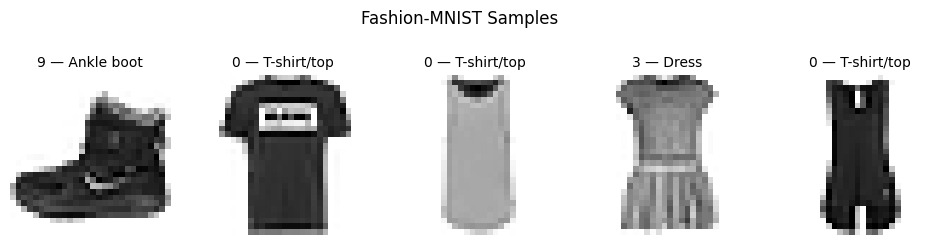

In [59]:
# Plot some samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('Fashion-MNIST Samples')
for i, ax in enumerate(axes):
    ax.imshow(trainX[i, :, :, 0], cmap='gray_r')
    ax.set_title(f"{trainY[i]} — {CLASS_NAMES[trainY[i]]}", fontsize=10)
    ax.axis('off')

plt.show()

## 2. Data preparation

In [60]:
trainY_encoded = to_categorical(trainY, 10)
testY_encoded  = to_categorical(testY, 10)

## 3. The Deep Learning model

In [61]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

# Use of Adam (Adaptive Moment Estimation) as the parameter optimizer. More info here: https://www.geeksforgeeks.org/deep-learning/adam-optimizer
opt = Adam(learning_rate=1e-04)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Plot information about the model
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,462,538 (5.58 MB)

 Trainable params: 1,462,538 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(trainX, trainY_encoded, validation_data=(testX, testY_encoded), batch_size=32, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6504 - loss: 4.9176 - val_accuracy: 0.7232 - val_loss: 0.7693
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6970 - loss: 1.0195 - val_accuracy: 0.7790 - val_loss: 0.6332
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7363 - loss: 0.7969 - val_accuracy: 0.7761 - val_loss: 0.5696
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7661 - loss: 0.6922 - val_accuracy: 0.8184 - val_loss: 0.5199
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7844 - loss: 0.6386 - val_accuracy: 0.8172 - val_loss: 0.4913
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8013 - loss: 0.5715 - val_accuracy: 0.8291 - val_loss: 0.4929
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8126 - loss: 0.5374 - val_accuracy: 0.7993 - val_loss: 0.5212
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8232 - loss: 0.5094 -

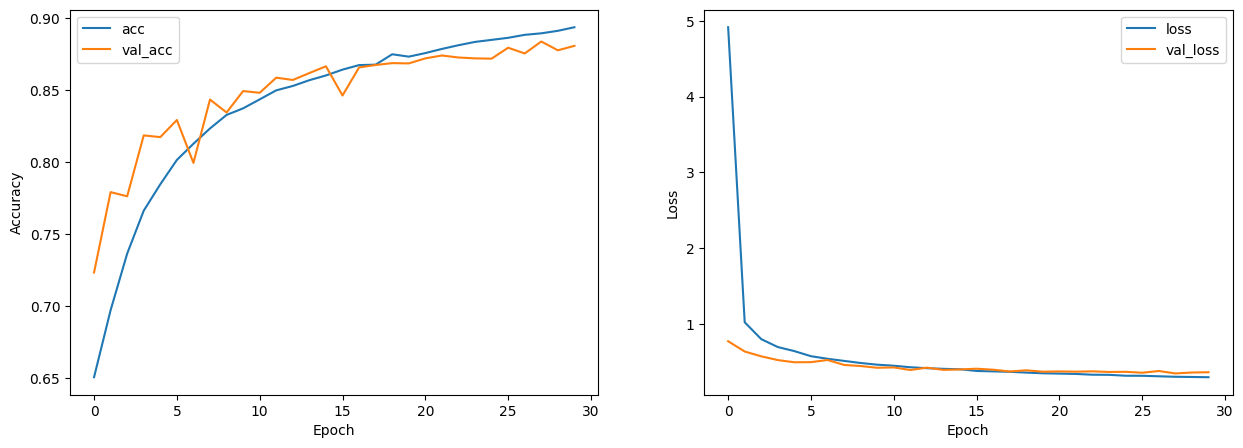

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: accuracy
ax1.plot(history.history['accuracy'], label='acc')
ax1.plot(history.history['val_accuracy'], label='val_acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right: loss
ax2.plot(history.history['loss'], label='loss')
ax2.plot(history.history['val_loss'], label='val_loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

## 5. Testing the network

A number is not an analysis. Let's look at **where** and **why** your model fails.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


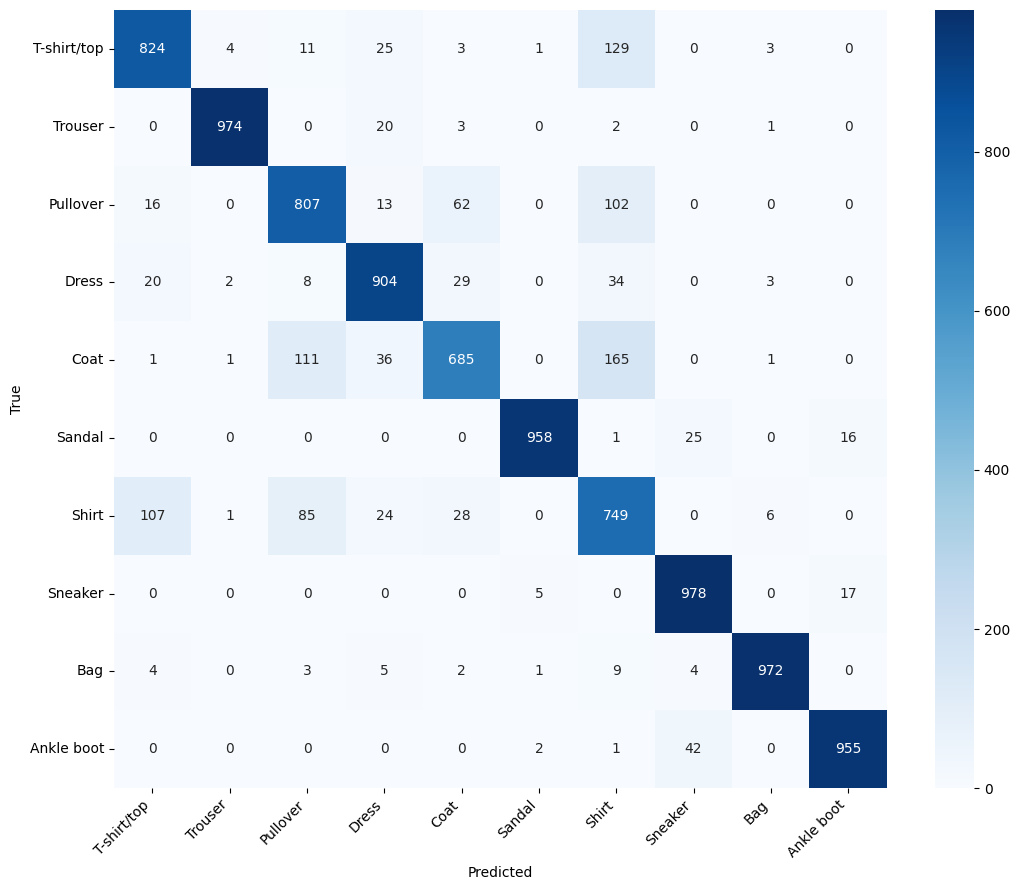

In [64]:
predicted = model.predict(testX)
predictedClass = np.argmax(predicted, axis=1)

# Confusion matrix
cm = confusion_matrix(testY, predictedClass)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Efficiency Challenge

In the real world, models run on phones, robots, and embedded devices. Parameters cost memory, latency, and energy.

**The challenge:** reach **≥ 85% validation accuracy** with a model of **≤ 150,000 trainable parameters** (weights + biases)